In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import urllib.request
import io

url = "https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%206%20-%20Applications%20for%20Data%20Analysis/W6D2%20-%20Advanced%20Numpy/globalpowerplantdatabasev130.zip"

with urllib.request.urlopen(url) as response:
    zip_bytes = io.BytesIO(response.read())

with zipfile.ZipFile(zip_bytes) as z:
    with z.open("global_power_plant_database.csv") as f:
        df = pd.read_csv(f, low_memory=False)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())


Shape: (34936, 36)

Columns: ['country', 'country_long', 'name', 'gppd_idnr', 'capacity_mw', 'latitude', 'longitude', 'primary_fuel', 'other_fuel1', 'other_fuel2', 'other_fuel3', 'commissioning_year', 'owner', 'source', 'url', 'geolocation_source', 'wepp_id', 'year_of_capacity_data', 'generation_gwh_2013', 'generation_gwh_2014', 'generation_gwh_2015', 'generation_gwh_2016', 'generation_gwh_2017', 'generation_gwh_2018', 'generation_gwh_2019', 'generation_data_source', 'estimated_generation_gwh_2013', 'estimated_generation_gwh_2014', 'estimated_generation_gwh_2015', 'estimated_generation_gwh_2016', 'estimated_generation_gwh_2017', 'estimated_generation_note_2013', 'estimated_generation_note_2014', 'estimated_generation_note_2015', 'estimated_generation_note_2016', 'estimated_generation_note_2017']


# Daily Challenge — Global Power Plant Database Analysis

**Dataset:** World Resources Institute Global Power Plant Database (34,936 plants, 36 columns) 

In [3]:
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print("Missing values (%) - top 15 worst columns:")
print(missing_pct.head(15))

print("\nKey columns missing %:")
print(missing_pct[['capacity_mw', 'primary_fuel', 'commissioning_year', 'latitude', 'longitude']])


Missing values (%) - top 15 worst columns:
other_fuel3                      99.736661
other_fuel2                      99.209984
other_fuel1                      94.435539
generation_gwh_2013              81.632127
generation_gwh_2014              79.316464
generation_gwh_2015              76.519922
generation_gwh_2016              73.826425
generation_gwh_2017              72.807419
generation_gwh_2018              72.415274
generation_gwh_2019              72.352301
generation_data_source           67.368903
year_of_capacity_data            57.387795
estimated_generation_gwh_2013    53.858484
wepp_id                          53.532173
estimated_generation_gwh_2014    52.762194
dtype: float64

Key columns missing %:
capacity_mw            0.00000
primary_fuel           0.00000
commissioning_year    50.06011
latitude               0.00000
longitude              0.00000
dtype: float64


## Data Cleaning

The key analytical columns (`capacity_mw`, `primary_fuel`, `latitude`, `longitude`) are 100% complete — no cleaning needed there. The `other_fuel1/2/3`, generation-by-year, and `wepp_id` columns are 50-99% empty and are not central to this analysis, so they are left as-is rather than imputed. The one significant gap is `commissioning_year` (50% missing) — dropping half the dataset would be wasteful, so for the time-series task we will filter to only the rows that DO have a year, rather than dropping or imputing globally.


In [4]:
df['capacity_mw'] = pd.to_numeric(df['capacity_mw'], errors='coerce')
df['commissioning_year'] = pd.to_numeric(df['commissioning_year'], errors='coerce')

print("capacity_mw dtype:", df['capacity_mw'].dtype)
print("commissioning_year dtype:", df['commissioning_year'].dtype)
print("\nAny non-numeric capacity values that became NaN?", df['capacity_mw'].isnull().sum())

capacity_mw dtype: float64
commissioning_year dtype: float64

Any non-numeric capacity values that became NaN? 0


## Exploratory Data Analysis

In [5]:
print("Capacity (MW) summary statistics:")
print(df['capacity_mw'].describe())

print("\n\nTop 10 countries by number of power plants:")
print(df['country_long'].value_counts().head(10))

print("\n\nDistribution by fuel type:")
print(df['primary_fuel'].value_counts())

Capacity (MW) summary statistics:
count    34936.000000
mean       163.355148
std        489.636072
min          1.000000
25%          4.900000
50%         16.745000
75%         75.344250
max      22500.000000
Name: capacity_mw, dtype: float64


Top 10 countries by number of power plants:
country_long
United States of America    9833
China                       4235
United Kingdom              2751
Brazil                      2360
France                      2155
India                       1589
Germany                     1309
Canada                      1159
Spain                        829
Russia                       545
Name: count, dtype: int64


Distribution by fuel type:
primary_fuel
Solar             10665
Hydro              7156
Wind               5344
Gas                3998
Coal               2330
Oil                2320
Biomass            1430
Waste              1068
Nuclear             195
Geothermal          189
Storage             135
Other                43
Cogeneratio

In [6]:
from scipy.stats import skew, kurtosis

capacity_skew = skew(df['capacity_mw'].dropna())
capacity_kurt = kurtosis(df['capacity_mw'].dropna())

print(f"Skewness of capacity_mw: {capacity_skew:.2f}")
print(f"Kurtosis of capacity_mw: {capacity_kurt:.2f}")

Skewness of capacity_mw: 8.90
Kurtosis of capacity_mw: 192.91


Global power plant capacity is extremely positively skewed (skewness = 8.90) with very high kurtosis (192.91). This confirms numerically what the mean/median gap suggested: most power plants are small (median 16.7 MW), but a small number of massive plants (up to 22,500 MW) — likely large hydroelectric dams or nuclear facilities — pull the average far above the typical plant size. This is a direct real-world example of today's lesson on skewness/kurtosis: a plain average would badly mislead anyone trying to understand a "typical" power plant.

## Statistical Analysis: Capacity by Fuel Type

In [7]:
fuel_stats = df.groupby('primary_fuel')['capacity_mw'].agg(['mean', 'median', 'std', 'count']).sort_values('mean', ascending=False)
print(fuel_stats)

                       mean      median          std  count
primary_fuel                                               
Nuclear         2091.855179  1888.00000  1303.509273    195
Coal             843.579828   600.00000   888.187187   2330
Gas              373.449375   147.50000   560.934146   3998
Petcoke          202.048125    65.48875   476.986459     12
Hydro            147.171551    20.00000   549.809328   7156
Oil              112.878754     9.00000   392.009039   2320
Cogeneration      98.731707    31.90000   283.428252     41
Other             84.020000    40.00000   145.891392     43
Geothermal        67.130952    30.00000   114.640890    189
Wave and Tidal    55.220000     5.00000   101.440708     10
Wind              49.224126    27.00000   106.138355   5344
Biomass           23.972938     9.45000    39.461805   1430
Solar             17.657039     5.80000    41.939412  10665
Waste             13.809657     4.80000    20.582503   1068
Storage           12.683704     4.90000 

## Hypothesis Testing: Does Mean Capacity Differ Between Fuel Types?

In [8]:
from scipy import stats

solar_capacity = df[df['primary_fuel'] == 'Solar']['capacity_mw'].dropna()
hydro_capacity = df[df['primary_fuel'] == 'Hydro']['capacity_mw'].dropna()

t_stat, p_value = stats.ttest_ind(solar_capacity, hydro_capacity, equal_var=False)

print(f"H0: Mean capacity is the same for Solar and Hydro plants")
print(f"H1: Mean capacity differs between Solar and Hydro plants")
print(f"\nSolar mean: {solar_capacity.mean():.2f} MW (n={len(solar_capacity)})")
print(f"Hydro mean: {hydro_capacity.mean():.2f} MW (n={len(hydro_capacity)})")
print(f"\nT-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.10f}")

alpha = 0.05
if p_value < alpha:
    print(f"\nSince p-value < {alpha}, we REJECT H0 — the difference is statistically significant.")
else:
    print(f"\nSince p-value >= {alpha}, we FAIL TO REJECT H0.")

H0: Mean capacity is the same for Solar and Hydro plants
H1: Mean capacity differs between Solar and Hydro plants

Solar mean: 17.66 MW (n=10665)
Hydro mean: 147.17 MW (n=7156)

T-statistic: -19.89
P-value: 0.0000000000

Since p-value < 0.05, we REJECT H0 — the difference is statistically significant.


The t-test conclusively rejects the null hypothesis (p ≈ 0) — Solar plants (mean 17.66 MW) and Hydro plants (mean 147.17 MW) have significantly different average capacities. This is expected physically: Hydro plants require large-scale dam infrastructure and are typically built as major centralized facilities, while Solar installations can be deployed at almost any scale, from small rooftop arrays to utility-scale farms, pulling the average down.

## Time Series Analysis: Fuel Mix Evolution Over Time

In [9]:
df_with_year = df[df['commissioning_year'].notna()].copy()
df_with_year['decade'] = (df_with_year['commissioning_year'] // 10 * 10).astype(int)

print(f"Plants with a known commissioning year: {len(df_with_year)} out of {len(df)} ({len(df_with_year)/len(df)*100:.1f}%)")
print("\nEarliest plant:", int(df_with_year['commissioning_year'].min()))
print("Most recent plant:", int(df_with_year['commissioning_year'].max()))

decade_fuel = df_with_year.groupby(['decade', 'primary_fuel']).size().unstack(fill_value=0)
print("\nPlants built per decade by fuel type (last 6 decades):")
print(decade_fuel.tail(6))


Plants with a known commissioning year: 17447 out of 34936 (49.9%)

Earliest plant: 1896
Most recent plant: 2020

Plants built per decade by fuel type (last 6 decades):
primary_fuel  Biomass  Coal  Cogeneration  Gas  Geothermal  Hydro  Nuclear  \
decade                                                                       
1970               28   176             3  220           7    283       34   
1980               51   204             7  280          27    536       48   
1990               60   230             8  491          42    371        5   
2000              223   555             6  915          33    464        6   
2010              192   558             7  564          31    523        4   
2020                1     0             0    6           0      0        0   

primary_fuel  Oil  Other  Petcoke  Solar  Storage  Waste  Wind  
decade                                                          
1970          188      0        2      0        0     10     1  
1980       

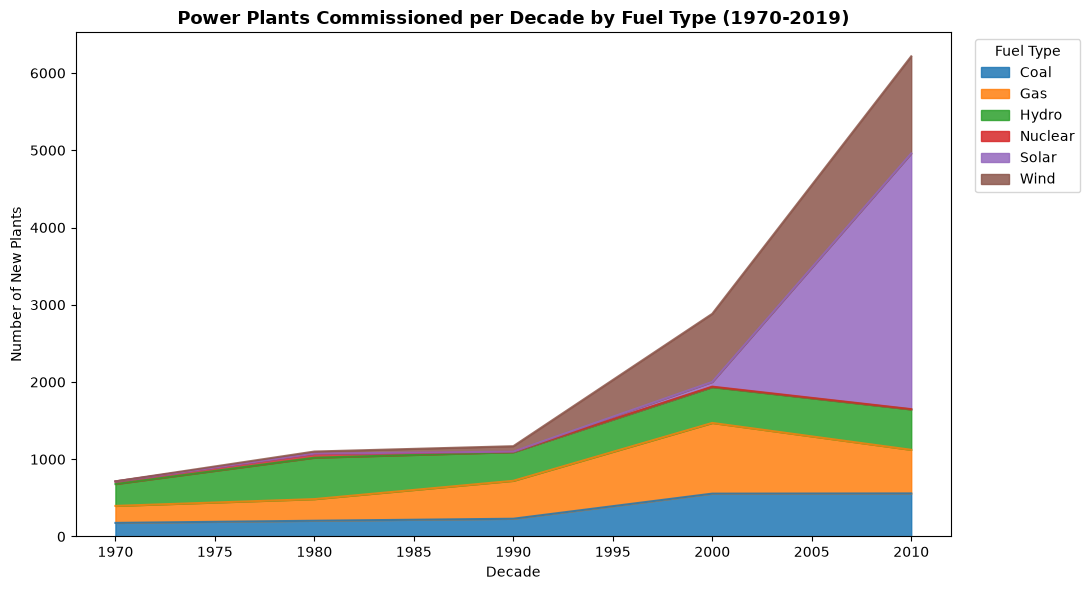

In [10]:
recent = decade_fuel.loc[1970:2010]
key_fuels = ['Coal', 'Gas', 'Hydro', 'Nuclear', 'Solar', 'Wind']

plt.figure(figsize=(11, 6))
recent[key_fuels].plot(kind='area', stacked=True, ax=plt.gca(), alpha=0.85)
plt.title('Power Plants Commissioned per Decade by Fuel Type (1970-2019)', fontsize=13, fontweight='bold')
plt.xlabel('Decade')
plt.ylabel('Number of New Plants')
plt.legend(title='Fuel Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

The stacked area chart makes the shift undeniable: Solar and Wind were essentially nonexistent before 2000, but by the 2010s they represent the majority of new power plant capacity added, with Solar alone (purple) becoming the single largest category. Coal's growth, by contrast, plateaued around 2000 and stayed flat — it did not decline in absolute terms, but its *share* of new plants shrank dramatically as renewables scaled up.

In [11]:
coal_by_country_decade = df_with_year[df_with_year['primary_fuel'] == 'Coal'].groupby(['country_long', 'decade']).size().unstack(fill_value=0)

coal_2000s_plus = coal_by_country_decade[[c for c in [1990, 2000, 2010] if c in coal_by_country_decade.columns]]
coal_2000s_plus['growth_1990_to_2010'] = coal_2000s_plus.get(2010, 0) - coal_2000s_plus.get(1990, 0)

print("Top 10 countries by Coal plant growth (1990s → 2010s):")
print(coal_2000s_plus.sort_values('growth_1990_to_2010', ascending=False).head(10))

Top 10 countries by Coal plant growth (1990s → 2010s):
decade        1990  2000  2010  growth_1990_to_2010
country_long                                       
China           90   446   359                  269
India           23    40   103                   80
Indonesia        2     2    16                   14
Philippines      3     5    12                    9
Pakistan         1     0     6                    5
South Korea      1     1     6                    5
Guatemala        0     2     3                    3
Brazil           2     5     5                    3
Cambodia         0     0     2                    2
Vietnam          0     0     2                    2


**Deeper dive (self-directed):** the "flat" global Coal trend hides massive regional variation. China alone added 269 net new Coal plants between the 1990s and 2010s — more than 3x every other country on this list combined — with a clear boom in the 2000s (90→446 plants) that partially eased by the 2010s (359 plants). India shows a different pattern: steadier, still-accelerating growth (23→40→103) with no sign of slowing. This shows that a global "flat" trend can conceal very different national energy stories — a reminder to always check whether an aggregate number is masking real subgroup differences, the same principle from the Superstore project (Q4-Q6) where state-level averages hid branch-level problems.

In [12]:
gdp_billion_usd = {
    'China': 17700, 'India': 3732, 'Indonesia': 1417, 'Philippines': 512,
    'Pakistan': 338, 'South Korea': 1709, 'Guatemala': 113, 'Brazil': 2170,
    'Cambodia': 51, 'Vietnam': 484
}

coal_growth = coal_2000s_plus['growth_1990_to_2010']
comparison = pd.DataFrame({
    'coal_plant_growth': coal_growth,
    'gdp_billion_usd': [gdp_billion_usd.get(c, None) for c in coal_growth.index]
}).dropna()

correlation = comparison['coal_plant_growth'].corr(comparison['gdp_billion_usd'])
print(comparison.sort_values('gdp_billion_usd', ascending=False))
print(f"\nCorrelation between GDP and Coal plant growth: {correlation:.3f}")

              coal_plant_growth  gdp_billion_usd
country_long                                    
China                       269          17700.0
India                        80           3732.0
Brazil                        3           2170.0
South Korea                   5           1709.0
Indonesia                    14           1417.0
Philippines                   9            512.0
Vietnam                       2            484.0
Pakistan                      5            338.0
Guatemala                     3            113.0
Cambodia                      2             51.0

Correlation between GDP and Coal plant growth: 0.986


**GDP correlation (self-directed follow-up):** Coal plant growth (1990s→2010s) correlates extremely strongly with 2024 GDP (r = 0.986) across the top 10 growing countries — China's massive coal build-out lines up with its position as the world's second-largest economy, and the pattern holds down the list. However, this is very likely correlation without direct causation: both GDP and coal-plant growth are probably driven by a shared underlying factor — the scale of a country's industrialization and population — rather than a bigger economy directly *causing* more coal plants to be built. A useful reminder that a strong correlation is a starting point for a hypothesis, not proof of a mechanism.

## Advanced Visualization:

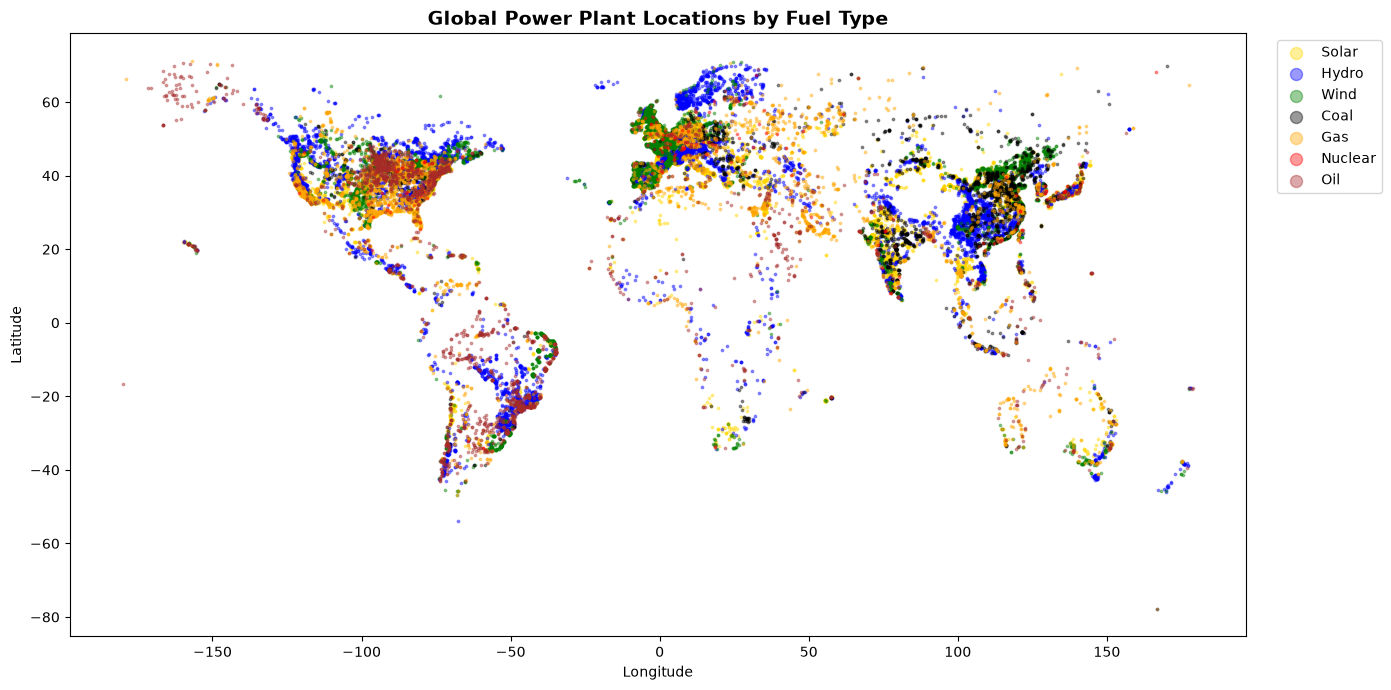

In [13]:
plt.figure(figsize=(14, 7))
fuel_colors = {'Solar': 'gold', 'Hydro': 'blue', 'Wind': 'green', 'Coal': 'black',
               'Gas': 'orange', 'Nuclear': 'red', 'Oil': 'brown'}

for fuel, color in fuel_colors.items():
    subset = df[df['primary_fuel'] == fuel]
    plt.scatter(subset['longitude'], subset['latitude'], s=3, alpha=0.4, c=color, label=fuel)

plt.title('Global Power Plant Locations by Fuel Type', fontsize=14, fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(markerscale=5, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

The geographic plot confirms our numeric findings visually: China shows a dense concentration of Coal (black) plants, directly matching the country-level Coal growth analysis above. Hydro (blue) clusters in mountainous, river-rich regions (Scandinavia, the Alps, Brazil, Southeast Asia), while Gas and Wind dominate the US and Europe. This shows fuel type isn't randomly distributed — it's shaped by geography (rivers for Hydro, wind corridors for Wind) and industrial policy (Coal in China).

## Matrix Operations in Real-World Context

In [14]:
numeric_cols = df[['capacity_mw', 'latitude', 'longitude']].dropna()

correlation_matrix = numeric_cols.corr()
print("Correlation matrix (capacity, latitude, longitude):")
print(correlation_matrix)

eigenvalues, eigenvectors = np.linalg.eig(correlation_matrix)
print("\nEigenvalues:", eigenvalues)
print("\nEigenvectors:\n", eigenvectors)

Correlation matrix (capacity, latitude, longitude):
             capacity_mw  latitude  longitude
capacity_mw     1.000000 -0.013218   0.151525
latitude       -0.013218  1.000000  -0.068354
longitude       0.151525 -0.068354   1.000000

Eigenvalues: [1.17147434+0.j 0.83840686+0.j 0.9901188 +0.j]

Eigenvectors:
 [[-0.63986801+0.j  0.65138323+0.j  0.40776072+0.j]
 [ 0.32661662+0.j -0.24978272+0.j  0.91155372+0.j]
 [-0.69562239+0.j -0.7164555 +0.j  0.05292462+0.j]]


## Matrix Operations: Eigenvector Analysis

The eigenvalues of the capacity/latitude/longitude correlation matrix (1.17, 0.84, 0.99) are all close to 1 and roughly equal — this confirms numerically what the correlation matrix already suggested: these three attributes are largely independent of each other, with no single dominant combined pattern explaining most of the variation. Had these variables been strongly related, one eigenvalue would have been noticeably larger than the others. This is directly relevant to real-world applications: this same eigenvector technique is the foundation of PCA (Principal Component Analysis), a common method for simplifying complex, high-dimensional datasets by finding their most important underlying directions of variation — a technique commonly used before feeding data into machine learning models.

## Integrating NumPy with Pandas and Matplotlib:

Large Northern Hemisphere plants (>500 MW): 2996


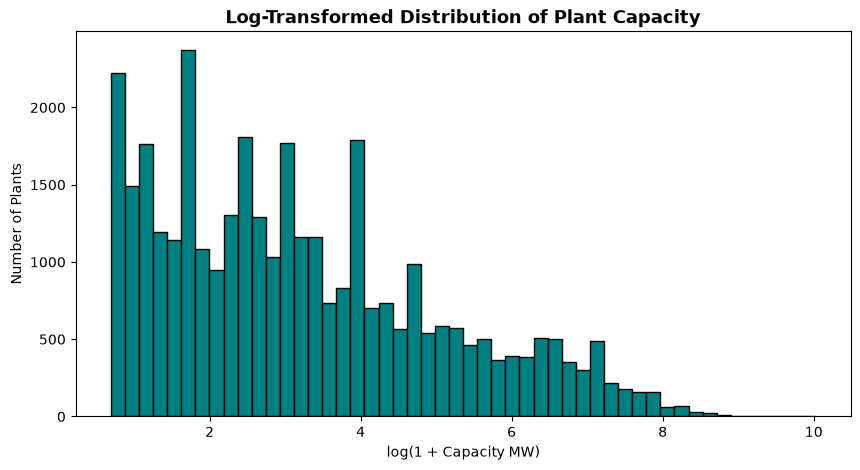

In [15]:
# Example 1: NumPy for complex filtering in Pandas
# Find plants that are BOTH large AND in the top half of the world by latitude (Northern hemisphere, big plants)
complex_filter = df[np.logical_and(df['capacity_mw'] > 500, df['latitude'] > 0)]
print(f"Large Northern Hemisphere plants (>500 MW): {len(complex_filter)}")

# Example 2: NumPy for a smarter Matplotlib plot — using np.log1p to fix the skewed capacity data
plt.figure(figsize=(10, 5))
plt.hist(np.log1p(df['capacity_mw'].dropna()), bins=50, color='teal', edgecolor='black')
plt.title('Log-Transformed Distribution of Plant Capacity', fontsize=13, fontweight='bold')
plt.xlabel('log(1 + Capacity MW)')
plt.ylabel('Number of Plants')
plt.show()

## Integrating NumPy with Pandas and Matplotlib

`np.logical_and()` enables precise multi-condition filtering in Pandas (e.g., isolating large Northern Hemisphere plants). `np.log1p()` demonstrates how NumPy directly improves a Matplotlib visualization: applying a log transform to the highly skewed capacity data (skewness = 8.90) turns an unreadable, cramped histogram into a clear, spread-out distribution — a standard technique for visualizing real-world data that clusters near small values with a long tail of outliers.

## Summary of Key Findings

1. Global power plant capacity is extremely positively skewed (8.90) — most plants are small (median 16.7 MW) but a few massive plants (up to 22,500 MW) pull the average far above typical.
2. Solar and Hydro plants differ significantly in size (p ≈ 0) — Hydro averages 147 MW vs. Solar's 18 MW, reflecting large centralized dam infrastructure vs. flexible, small-scale solar deployment.
3. Renewable energy adoption has exploded since 2000: Solar went from 0 plants in the 1970s-80s to 3,310 new plants in the 2010s alone.
4. Global Coal growth appeared "flat" but was actually driven almost entirely by China (+269 net plants, 1990s→2010s) — a strong reminder to check whether aggregate trends hide major subgroup differences.
5. Coal plant growth correlates strongly with national GDP (r = 0.986) across major growing countries, though this likely reflects shared underlying industrialization/population scale rather than direct causation.
6. Capacity, latitude, and longitude are essentially unrelated (eigenvalues all close to 1) — a plant's size has no meaningful geographic pattern.